In [19]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import os
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
# from matplotlib.ticker import FormatStrFormatter



In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
# stim meta df
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)


# human results df  
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))


## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)



# human results df

# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


# filter for participants that passed the catch trials

len(results.participant.unique())
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index
good_results = results[results.participant.isin(good_participants)]


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


## Get Model Results

In [4]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')
timit_results = list(parent_path.rglob("TIMIT_attn_task*all_targets_*/*/*.csv"))
timit_results

[PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_1/metrics.csv'),
 PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_match_cue_speech_and_noise/version_0/metrics.csv'),
 PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_BinauralCueWLReportW/version_10/metrics.csv'),
 PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_BinauralCueWLReportW/version_11/metrics.csv'),
 PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_BinauralCueWLReportW/version_9/metrics.csv'),
 PosixPath('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_MonauralFBA/version_

In [5]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')
timit_results = list(parent_path.rglob("TIMIT_attn_task*all_targets_*/*/*.csv"))

# TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
# timit_results = list(parent_path.rglob("*.csv"))

wanted_models = ['MultiDistractorAttnCNN',
                 'match_cue_speech_and_noise/',
                 'global_attn_speech_and_noise',
                 'fc_attn_only',  
                 'coch_attn_only',   
                 'per_kernel_attn_only',
                 'concat_attn',
                 'dual_channel_attn',
                 ]

timit_results = [path.as_posix() for path in timit_results 
                 if any(model in path.as_posix() for model in wanted_models)
                 and ('clean' not in path.as_posix()) and ('version_0' in path.as_posix())]
timit_results

['/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_match_cue_speech_and_noise/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_coch_attn_only/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_concat_attn/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_dual_channel_attn/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_fc_attn_only/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_global_attn_speech_and_noise/version_0/metrics.csv',
 '/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/T

In [6]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [7]:
## Make model results df 

model_results = []

for path in timit_results:
#     if "-20_to_20dB" in path:
#         continue 
    if ('TIMIT_attn_task_all_targets_MultiDistractorAttnCNN' in path) and ('version_3' in path):
        continue
    if ("batch_norm" in path) and ('version_0' in path):
        continue 
    df = pd.read_csv(path)
    print(path)
    df['model'] = re.search('_targets_(.+?)/', path).group(1)
    df = df.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in df.index})
    df['pred_word_ix'] = df['pred_word_ix'].astype('int') 
    df['guessed_word'] = df['pred_word_ix'].map(class_map)

    ### Get metadata from timit df 
    df['true_word'] = model_meta_df.loc[df.orig_df_ix, ['word']].values
    df['distractor_words'] = model_meta_df.loc[df.orig_df_ix, ['distractor_words']].values
    df['distractor_sex'] = model_meta_df.loc[df.orig_df_ix, ['distractor_sex']].values
    df['snr'] = model_meta_df.loc[df.orig_df_ix, ['snrs']].values.astype('str')
    df['distractor_condition'] = model_meta_df.loc[df.orig_df_ix, ['distractor_conditions']].values.astype('str')
    df['target_sex'] = model_meta_df.loc[df.orig_df_ix, ['speaker_sex']].values
    df['confusions'] = df[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

    
    model_results.append(df)
model_results = pd.concat(model_results, axis=0, ignore_index=True)
model_results = model_results.replace('ssn', 'noise', regex=True)

/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_match_cue_speech_and_noise/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_coch_attn_only/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_concat_attn/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_dual_channel_attn/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_fc_attn_only/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_global_attn_speech_and_noise/version_0/metrics.csv
/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_target

In [8]:
model_results.model.unique()

array(['match_cue_speech_and_noise', 'coch_attn_only', 'concat_attn',
       'dual_channel_attn', 'fc_attn_only',
       'global_attn_speech_and_noise', 'per_kernel_attn_only',
       'MultiDistractorAttnCNN'], dtype=object)

In [9]:
model_results['model'].replace('MultiDistractorAttnCNN','original model', inplace=True)
model_results['model'].replace('match_cue_speech_and_noise','match cue & target level', inplace=True)
model_results['model'].replace('global_attn_speech_and_noise','global_attn', inplace=True)

## Compare results 

In [10]:
## Prep dfs for plots 
model_results['subject'] = 'model'
good_results['subject'] = 'human'

all_results = pd.concat([good_results, model_results])
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)
# set model field to human for plotting human data
all_results.loc[all_results['subject'] == 'human', 'model'] = 'human'

## get turk macro dfs
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())


/tmp/ipykernel_1181850/1691315551.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [11]:
all_results.snr.unique()

array(['-6', '3', '-3', '-9', '0', 'clean'], dtype=object)

In [12]:
all_results.model.unique()

array(['human', 'match cue & target level', 'coch_attn_only',
       'concat_attn', 'dual_channel_attn', 'fc_attn_only', 'global_attn',
       'per_kernel_attn_only', 'original model'], dtype=object)

Text(0.5, 0.98, 'Single distractor performance comparison')

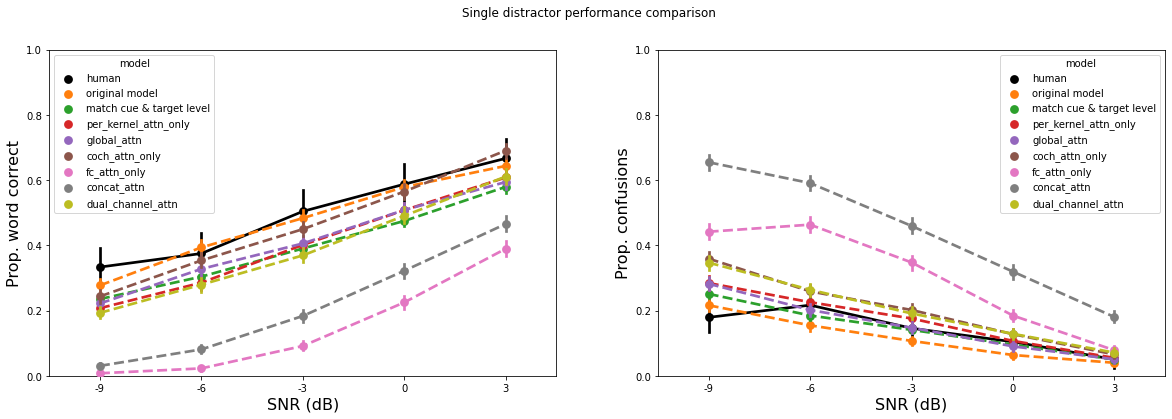

In [20]:
snr_order = ['-9', '-6', '-3', '0', '3']
# hue_order = ['1', '4', 'noise']

model_order = ['human', 'original model', 'match cue & target level',  'per_kernel_attn_only', 'global_attn', 'coch_attn_only', 'fc_attn_only', 'concat_attn',  'dual_channel_attn']

cmap = sns.color_palette("tab10", len(model_order), as_cmap=False)
model_hue = {model:cmap[ix] for ix, model in enumerate(model_order)}
model_hue['human'] = 'k' # set human to black line 

model_line_style = {model:'-' if model == 'human' else'--' for model in model_order}

# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

# distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
# distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
# distractor_palette['noise'] = 'grey'

fig, axs = plt.subplots(1,2, figsize=(20,6))

g = sns.pointplot(
            data=all_results[all_results.distractor_condition == "1"],
            x = 'snr', y = 'accuracy', order=snr_order, hue_order=model_order,
            col='distractor_condition', #col_order = hue_order,
            hue ='model', linestyles=list(model_line_style.values()),
            palette=model_hue,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4,
            ax = axs[0]
            )

g = sns.pointplot(
            data=all_results[all_results.distractor_condition == '1'],
            x = 'snr', y = 'confusions', order=snr_order,  hue_order=model_order,
            col='distractor_condition', #col_order = hue_order,
            hue ='model', linestyles=list(model_line_style.values()),
            palette=model_hue,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4,
            ax = axs[1]
            )
axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)

np.vectorize(lambda x: x.set_xlabel("SNR (dB)", fontsize=fontsize))(axs)

axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

plt.suptitle('Single distractor performance comparison')

In [14]:
grouped_results = all_results.groupby(['model', 'distractor_condition', 'snr' ]).accuracy.agg(['mean', 'sem']).reset_index()

In [27]:
def calc_r_squared(true, pred):
    ssr = np.sum((pred - true)**2)
    tss = np.sum((true - np.mean(true))**2)
    return 1 - (ssr / tss)


In [28]:
turk_summary_df

,snr,participant,distractor_condition,mean
0,-3,p12_1,1,0.800000
1,-3,p12_1,2,0.300000
2,-3,p12_1,4,0.300000
3,-3,p12_1,noise,0.400000
4,-3,p18_1,1,0.500000
...,...,...,...,...
427,clean,p5_1,catch_trial,0.833333
428,clean,p5_2,catch_trial,1.000000
429,clean,p6_2,catch_trial,0.916667
430,clean,p8_0,catch_trial,0.833333


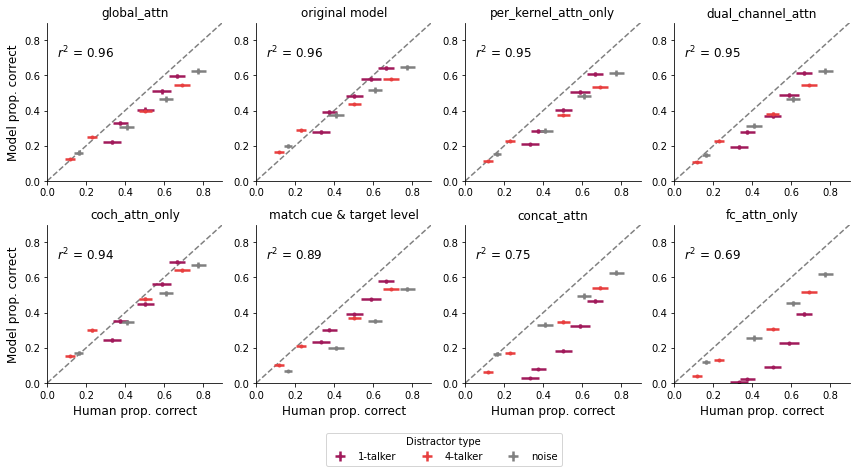

In [66]:


hue_order = ['1', '4', 'noise']


human_results = turk_summary_df.groupby(['distractor_condition', 'snr'])['mean'].agg(['mean', 'sem']).reset_index()
human_results = human_results[human_results.distractor_condition.isin(hue_order)]

grouped_results = all_results.groupby(['model', 'distractor_condition', 'snr' ]).accuracy.agg(['mean', 'sem']).reset_index()
grouped_results = grouped_results[grouped_results.distractor_condition.isin(hue_order)]


distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

x = y = np.linspace(0,1,5)

fontsize = 12

# get model order rank by r_squared
model_rsquared_dict = {}
for model in grouped_results.model.unique():
    if model == 'human':
        continue
    model_df = grouped_results[grouped_results.model == model]
    slope, intercept, r_value, p_value, std_err = stats.linregress(human_results["mean"].values, model_df["mean"].values)
    model_rsquared_dict[model] = r_value ** 2

model_order = sorted(model_rsquared_dict.keys(), key=lambda item: model_rsquared_dict[item], reverse=True)

fig, axs = plt.subplots(2,4, figsize=(12,6))
axs = axs.ravel()
for ix, model in enumerate(model_order):
    axs[ix].plot(x,y, ls='dashed', color='grey')
    model_df = grouped_results[grouped_results.model == model]
    for condition in hue_order:
        human_data = human_results[human_results.distractor_condition == condition]
        human_means = human_data["mean"].values
        human_errors = human_data["sem"].values

        model_data = model_df[model_df.distractor_condition == condition]
        model_means = model_data["mean"].values
        model_errors = model_data["sem"].values



        axs[ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='None', ms=3, elinewidth=2.5, label=condition,
                         ecolor=distractor_palette[condition], mfc=distractor_palette[condition], mec=distractor_palette[condition])
        # axs[ix].set_xlabel(f"Model prop. correct", fontsize=fontsize)
    axs[ix].set_xlim(0,0.9)
    axs[ix].set_ylim(0,0.9)
    axs[ix].set_title(f"{model}", fontsize=fontsize)
    if ix in [0, 4]:
        axs[ix].set_ylabel(f"Model prop. correct", fontsize=fontsize)
    if ix > 3:
        axs[ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(human_results["mean"].values, model_df["mean"].values)
    r_squared = r_value ** 2 
    axs[ix].annotate(f"$r^2$ = {r_squared:.2f}", (0.05, 0.7), fontsize=fontsize)

sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# plt.subplots_adjust(hspace=0.3)

fig.legend(lines, ['1-talker', '4-talker', 'noise'], bbox_to_anchor=(0.66, 0),bbox_transform=fig.transFigure, ncol=3, title='Distractor type')
plt.tight_layout()





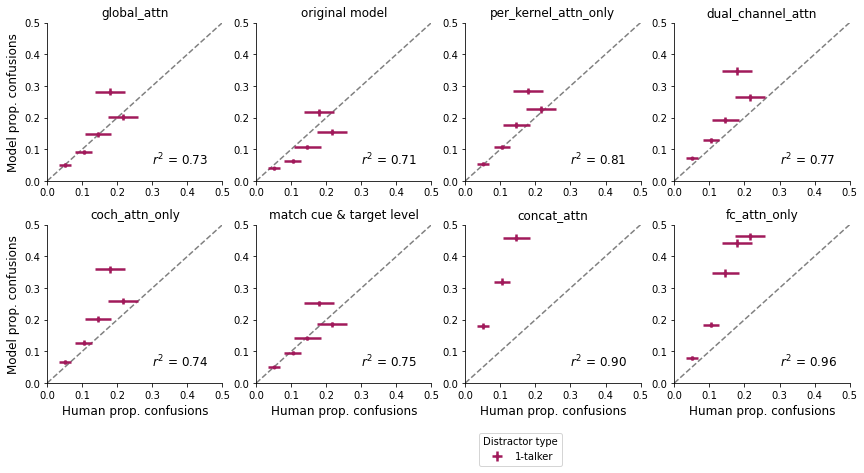

In [67]:


hue_order = ['1']


human_results = turk_conf_df.groupby(['distractor_condition', 'snr'])['mean'].agg(['mean', 'sem']).reset_index()
human_results = human_results[human_results.distractor_condition.isin(hue_order)]

grouped_results = all_results.groupby(['model', 'distractor_condition', 'snr' ])['confusions'].agg(['mean', 'sem']).reset_index()
grouped_results = grouped_results[grouped_results.distractor_condition.isin(hue_order)]


distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

x = y = np.linspace(0,1,5)

fontsize = 12


# get model order rank by r_squared
# model_rsquared_dict = {}
# for model in grouped_results.model.unique():
#     if model == 'human':
#         continue
#     model_df = grouped_results[grouped_results.model == model]
#     slope, intercept, r_value, p_value, std_err = stats.linregress(human_results["mean"].values, model_df["mean"].values)
#     model_rsquared_dict[model] = r_value ** 2

# model_order = sorted(model_rsquared_dict.keys(), key=lambda item: model_rsquared_dict[item], reverse=False)

fig, axs = plt.subplots(2,4, figsize=(12,6))
axs = axs.ravel()
for ix, model in enumerate(model_order):
    axs[ix].plot(x,y, ls='dashed', color='grey')
    model_df = grouped_results[grouped_results.model == model]
    for condition in hue_order:
        human_data = human_results[human_results.distractor_condition == condition]
        human_means = human_data["mean"].values
        human_errors = human_data["sem"].values

        model_data = model_df[model_df.distractor_condition == condition]
        model_means = model_data["mean"].values
        model_errors = model_data["sem"].values



        axs[ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='None', ms=3, elinewidth=2.5, label=condition,
                         ecolor=distractor_palette[condition], mfc=distractor_palette[condition], mec=distractor_palette[condition])
        # axs[ix].set_xlabel(f"Model prop. correct", fontsize=fontsize)
    axs[ix].set_xlim(0,0.5)
    axs[ix].set_ylim(0,0.5)
    axs[ix].set_title(f"{model}", fontsize=fontsize)
    if ix in [0, 4]:
        axs[ix].set_ylabel(f"Model prop. confusions", fontsize=fontsize)
    if ix > 3:
        axs[ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(human_results["mean"].values, model_df["mean"].values)
    r_squared = r_value ** 2 
    axs[ix].annotate(f"$r^2$ = {r_squared:.2f}", (0.3, 0.05), fontsize=fontsize)
sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# plt.subplots_adjust(hspace=0.3)

fig.legend(lines, ['1-talker', '4-talker', 'noise'], bbox_to_anchor=(0.66, 0),bbox_transform=fig.transFigure, ncol=3, title='Distractor type')
plt.tight_layout()





In [69]:
grouped_results = all_results.groupby(['model', 'distractor_condition', 'snr' ])[['accuracy', 'confusions']].agg(['mean', 'sem']).reset_index()
grouped_results = grouped_results[grouped_results.model.isin(wanted_models)]

grouped_results.head()

model distractor_condition snr  accuracy           confusions  \
                                                    mean       sem       mean   
34  dual_channel_attn                    1  -3  0.369180  0.011365   0.191242   
35  dual_channel_attn                    1  -6  0.279379  0.010567   0.263858   
36  dual_channel_attn                    1  -9  0.192905  0.009293   0.347007   
37  dual_channel_attn                    1   0  0.490576  0.011773   0.128603   
38  dual_channel_attn                    1   3  0.610865  0.011482   0.070953   

              
         sem  
34  0.009262  
35  0.010379  
36  0.011211  
37  0.007884  
38  0.006047

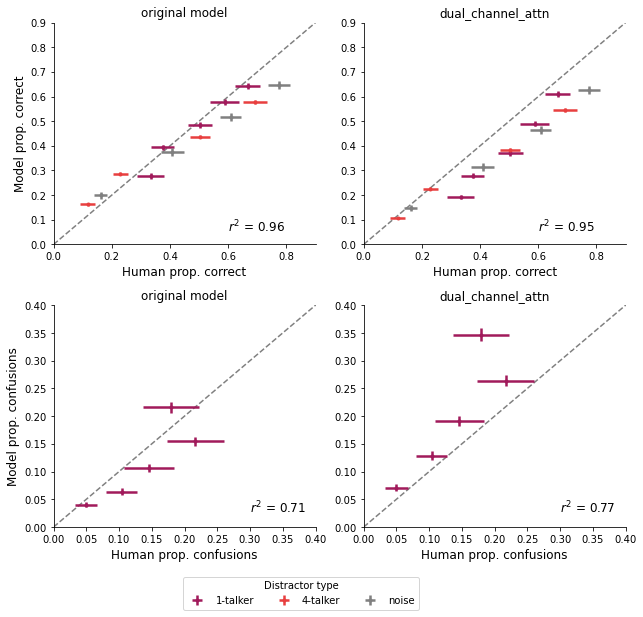

In [70]:
## Plot comparison to dual_channel models 

grouped_results = all_results.groupby(['model', 'distractor_condition', 'snr' ])[['accuracy', 'confusions']].agg(['mean', 'sem']).reset_index()
hue_order = ['1', '4', 'noise']

wanted_models = ['original model', "dual_channel_attn"]

grouped_results = grouped_results[grouped_results.model.isin(wanted_models)]


human_accuracy = turk_summary_df.groupby(['distractor_condition', 'snr'])['mean'].agg(['mean', 'sem']).reset_index()
human_accuracy = human_accuracy[human_accuracy.distractor_condition.isin(hue_order)]


human_confusions = turk_conf_df.groupby(['distractor_condition', 'snr'])['mean'].agg(['mean', 'sem']).reset_index()
human_confusions = human_confusions[human_confusions.distractor_condition == '1']


grouped_results = grouped_results[grouped_results.distractor_condition.isin(hue_order)]


distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

x = y = np.linspace(0,1,5)

fontsize = 12



fig, axs = plt.subplots(2,2, figsize=(9,8))

for ix, model in enumerate(wanted_models):
    axs[0,ix].plot(x,y, ls='dashed', color='grey')
    axs[1,ix].plot(x,y, ls='dashed', color='grey')
    model_df = grouped_results[grouped_results.model == model]
    for condition in hue_order:
        # plot acc 
        human_data = human_accuracy[human_accuracy.distractor_condition == condition]
        human_means = human_data["mean"].values
        human_errors = human_data["sem"].values

        model_data = model_df[model_df.distractor_condition == condition]['accuracy']
        model_means = model_data["mean"].values
        model_errors = model_data["sem"].values

        axs[0, ix].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='None', ms=3, elinewidth=2.5, label=condition,
                         ecolor=distractor_palette[condition], mfc=distractor_palette[condition], mec=distractor_palette[condition])

    # plot confusions
    human_conf_data = human_confusions[human_confusions.distractor_condition == '1']
    human_conf_means = human_conf_data["mean"].values
    human_conf_errors = human_conf_data["sem"].values

    model_conf_data = model_df[model_df.distractor_condition == '1']['confusions']
    model_conf_means = model_conf_data["mean"].values
    model_conf_errors = model_conf_data["sem"].values

    axs[1, ix].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='None', ms=3, elinewidth=2.5, label=condition,
                        ecolor=distractor_palette['1'], mfc=distractor_palette['1'], mec=distractor_palette['1'])

        


        # axs[ix].set_xlabel(f"Model prop. correct", fontsize=fontsize)
    axs[0,ix].set_xlim(0,0.9)
    axs[0,ix].set_ylim(0,0.9)
    axs[0,ix].set_title(f"{model}", fontsize=fontsize)
    axs[1,ix].set_title(f"{model}", fontsize=fontsize)

    axs[1,ix].set_xlim(0,0.4)
    axs[1,ix].set_ylim(0,0.4)

    axs[0,ix].set_xlabel(f"Human prop. correct", fontsize=fontsize)
    axs[1,ix].set_xlabel(f"Human prop. confusions", fontsize=fontsize)
    

    slope, intercept, r_value, p_value, std_err = stats.linregress(human_accuracy["mean"].values, model_df['accuracy']["mean"].values)
    r_squared = r_value ** 2 
    axs[0,ix].annotate(f"$r^2$ = {r_squared:.2f}", (0.6, 0.05), fontsize=fontsize)


    slope, intercept, r_value, p_value, std_err = stats.linregress(human_confusions["mean"].values, model_conf_means)
    r_squared = r_value ** 2 
    axs[1,ix].annotate(f"$r^2$ = {r_squared:.2f}", (0.3, 0.025), fontsize=fontsize)

axs[0, 0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1, 0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)
sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# plt.subplots_adjust(hspace=0.3)

fig.legend(lines, ['1-talker', '4-talker', 'noise'], bbox_to_anchor=(0.66, 0),bbox_transform=fig.transFigure, ncol=3, title='Distractor type')
plt.tight_layout()
# 




In [ ]:
labels

['1', '4', 'noise']